In [16]:
import os
import dotenv 
dotenv.load_dotenv()

from clearml import Task
Task.set_credentials(
     api_host="https://api.clear.ml",
     web_host="https://app.clear.ml",
     files_host="https://files.clear.ml",
     key=os.getenv('clear_ml_key'), # get it from https://app.clear.ml/settings/workspace-configuration
     secret=os.getenv('clear_ml_secret') # get it from https://app.clear.ml/settings/workspace-configuration
)

### Data Ingestion

In [17]:
from clearml import Dataset

# ds = Dataset.get(
#         dataset_name="nutrition5k_dataset",
#         dataset_project="NutritionAnalyser",
#         dataset_version="1.0.1"
#     )

# local_path = ds.get_local_copy()
local_path = "C:/Users/riwki/.clearml/cache/storage_manager/datasets/ds_b6323a4330fa49a8b2a210b61ed415fc"
print("Dataset path:", local_path)

Dataset path: C:/Users/riwki/.clearml/cache/storage_manager/datasets/ds_b6323a4330fa49a8b2a210b61ed415fc


#### Parse raw metadata

In [19]:
import os
import pandas as pd

"""""
Note: The structure of the metadata files is as follows:
dish_id, total_calories, total_mass, total_fat, total_carb, total_protein, ingr_1_id, ingr_1_name, ingr_1_grams, ingr_1_calories, ingr_1_fat, ingr_1_carb, ingr_1_protein, ingr_2_id, ingr_2_name, ...

Some dishes have more than 5 ingredients, while some have fewer.
"""""
# parse_basic, we only care about the first 6 columns for now (dish_id, total_calories, total_mass, total_fat, total_carb, total_protein)
def parse_basic(path):
    rows = []

    with open(path) as f:
        for line in f:
            parts = line.strip().split(",")

            # เอาแค่ 6 column แรก
            try:
                rows.append({
                    "dish_id": parts[0].replace("dish_", ""),
                    "total_calories": float(parts[1]),
                    "total_mass": float(parts[2]),
                    "total_fat": float(parts[3]),
                    "total_carb": float(parts[4]),
                    "total_protein": float(parts[5]),
                })
            except:
                continue

    return pd.DataFrame(rows)

In [20]:
# load both metadata files and concatenate them into a single dataframe
df1 = parse_basic(os.path.join(local_path, "dish_metadata_cafe1.csv"))
df2 = parse_basic(os.path.join(local_path, "dish_metadata_cafe2.csv"))

df = pd.concat([df1, df2], ignore_index=True)

print(df.shape)
df.head()

(5006, 6)


,dish_id,total_calories,total_mass,total_fat,total_carb,total_protein
0,1561662216,300.794281,193.0,12.387489,28.218290,18.633970
1,1562688426,137.569992,88.0,8.256000,5.190000,10.297000
2,1561662054,419.438782,292.0,23.838249,26.351543,25.910593
3,1562008979,382.936646,290.0,22.224644,10.173570,35.345387
4,1560455030,20.590000,103.0,0.148000,4.625000,0.956000


#### Map image path

In [21]:
# add image path column
df["image_path"] = df["dish_id"].apply(
    lambda x: os.path.join(local_path, f"dish_{x}_rgb.png")
)

# filter only rows where image exists
df = df[df["image_path"].apply(os.path.exists)] 
print("Final samples:", len(df))

Final samples: 3079


### Feature engineering

In [22]:
# remove rows with zero calories (these are likely errors in the data and will cause issues with log-transforming the target variable)
df_nozero = df[df["total_calories"] > 0]

In [23]:
import numpy as np

# log-transform nutritional values to reduce skewness in the distribution and make it easier for the model to learn
df_nozero["calories_log"] = np.log1p(df_nozero["total_calories"])
df_nozero["protein_log"] = np.log1p(df_nozero["total_protein"])
df_nozero["carb_log"] = np.log1p(df_nozero["total_carb"])
df_nozero["fat_log"] = np.log1p(df_nozero["total_fat"])

C:\Users\riwki\AppData\Local\Temp\ipykernel_30244\1982620918.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nozero["calories_log"] = np.log1p(df_nozero["total_calories"])
C:\Users\riwki\AppData\Local\Temp\ipykernel_30244\1982620918.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nozero["protein_log"] = np.log1p(df_nozero["total_protein"])
C:\Users\riwki\AppData\Local\Temp\ipykernel_30244\1982620918.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

In [24]:
df_nozero

,dish_id,total_calories,total_mass,total_fat,total_carb,total_protein,image_path,calories_log,protein_log,carb_log,fat_log
0,1561662216,300.794281,193.0,12.387489,28.218290,18.633970,C:/Users/riwki/.clearml/cache/storage_manager/...,5.709746,2.977261,3.374795,2.594321
2,1561662054,419.438782,292.0,23.838249,26.351543,25.910593,C:/Users/riwki/.clearml/cache/storage_manager/...,6.041299,3.292520,3.308773,3.212385
3,1562008979,382.936646,290.0,22.224644,10.173570,35.345387,C:/Users/riwki/.clearml/cache/storage_manager/...,5.950478,3.593067,2.413551,3.145214
4,1560455030,20.590000,103.0,0.148000,4.625000,0.956000,C:/Users/riwki/.clearml/cache/storage_manager/...,3.072230,0.670902,1.727221,0.138021
5,1558372433,74.360001,143.0,0.286000,0.429000,20.020000,C:/Users/riwki/.clearml/cache/storage_manager/...,4.322277,3.045474,0.356975,0.251537
...,...,...,...,...,...,...,...,...,...,...,...
4760,1563295334,228.540009,96.0,17.380001,1.492000,15.540001,C:/Users/riwki/.clearml/cache/storage_manager/...,5.436077,2.805782,0.913086,2.911263
4762,1566329234,262.625214,457.0,10.797179,21.224293,23.129114,C:/Users/riwki/.clearml/cache/storage_manager/...,5.574528,3.183419,3.101186,2.467860
4765,1562691737,485.676880,700.0,11.722251,70.597321,27.926394,C:/Users/riwki/.clearml/cache/storage_manager/...,6.187600,3.364754,4.271058,2.543353
4766,1558458496,53.130001,77.0,0.154000,13.860001,0.539000,C:/Users/riwki/.clearml/cache/storage_manager/...,3.991389,0.431133,2.698673,0.143234


In [25]:
from sklearn.model_selection import train_test_split

df_nozero["cal_bin"] = pd.qcut(df_nozero["total_calories"], q=5, labels=False) # create 5 bins of calories for stratified splitting

train_df, test_df = train_test_split(df_nozero, test_size=0.3, random_state=42, stratify=df_nozero["cal_bin"]) # stratify by calorie bins to ensure similar distribution of calories in train and test sets

train_df = train_df.drop(columns=["cal_bin"]).reset_index(drop=True)
test_df = test_df.drop(columns=["cal_bin"]).reset_index(drop=True)

print("Train:", len(train_df))
print("Test:", len(test_df))

Train: 2025
Test: 868


C:\Users\riwki\AppData\Local\Temp\ipykernel_30244\252110616.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nozero["cal_bin"] = pd.qcut(df_nozero["total_calories"], q=5, labels=False) # create 5 bins of calories for stratified splitting


In [26]:
print(train_df["total_calories"].describe())
print(test_df["total_calories"].describe())

count    2025.000000
mean      227.858598
std       196.585299
min         1.150000
25%        72.402824
50%       177.492004
75%       335.298004
max      1324.084961
Name: total_calories, dtype: float64
count     868.000000
mean      234.149466
std       236.866218
min         2.530000
25%        73.839996
50%       178.375000
75%       342.587609
max      3943.325195
Name: total_calories, dtype: float64


In [27]:
# select only the columns we need for training the model
train_df = train_df[[
    "image_path",
    "calories_log",
    "protein_log",
    "carb_log",
    "fat_log"
]]

test_df = test_df[[
    "image_path",
    "calories_log",
    "protein_log",
    "carb_log",
    "fat_log"
]]

In [28]:
train_df.head()
test_df.head()

,image_path,calories_log,protein_log,carb_log,fat_log
0,C:/Users/riwki/.clearml/cache/storage_manager/...,3.273743,0.431133,1.968510,0.207827
1,C:/Users/riwki/.clearml/cache/storage_manager/...,3.182395,0.348955,1.729190,0.442160
2,C:/Users/riwki/.clearml/cache/storage_manager/...,4.855875,1.578775,2.694373,2.133680
3,C:/Users/riwki/.clearml/cache/storage_manager/...,6.332753,3.399489,4.391865,2.742120
4,C:/Users/riwki/.clearml/cache/storage_manager/...,4.442679,1.607025,2.190358,1.803963


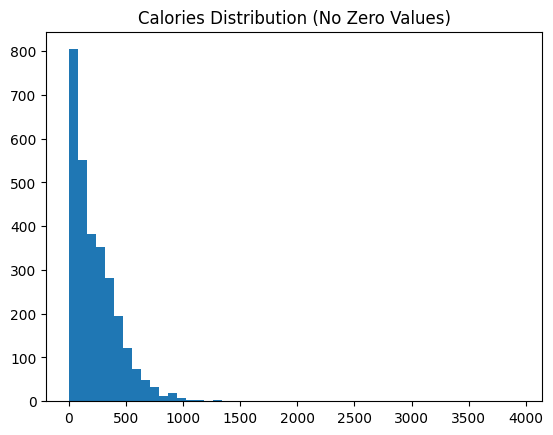

In [29]:
import matplotlib.pyplot as plt

plt.hist(df_nozero["total_calories"], bins=50)
plt.title("Calories Distribution (No Zero Values)")
plt.show()

In [30]:
print(df_nozero.isnull().sum())

dish_id           0
total_calories    0
total_mass        0
total_fat         0
total_carb        0
total_protein     0
image_path        0
calories_log      0
protein_log       0
carb_log          0
fat_log           0
cal_bin           0
dtype: int64


#### Data Augmentation

In [31]:
from torch.utils.data import Dataset
from PIL import Image

class FoodDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["image_path"]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        label = torch.tensor([
            row["calories_log"],
            row["protein_log"],
            row["carb_log"],
            row["fat_log"]
        ], dtype=torch.float32)

        return img, label

In [32]:
import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
from torch.utils.data import Dataset, DataLoader

train_loader = DataLoader(
    FoodDataset(train_df, train_transform),
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    FoodDataset(test_df, test_transform),
    batch_size=32
)

In [34]:
len(train_loader.dataset), len(test_loader.dataset)

(2025, 868)

## Train Model

In [35]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 4)

C:\Users\riwki\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\riwki\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [36]:
import torch.optim as optim
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [37]:
for epoch in range(5):
    model.train()
    total_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}")

Epoch 1, Loss: 3.3529
Epoch 2, Loss: 0.3774
Epoch 3, Loss: 0.2981
Epoch 4, Loss: 0.2524
Epoch 5, Loss: 0.1886


In [38]:
model.eval()
val_loss = 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)
        loss = criterion(outputs, labels)
        val_loss += loss.item()

print("Validation Loss:", val_loss / len(test_loader))

Validation Loss: 0.26591790094971657


In [39]:
import numpy as np

outputs_real = np.expm1(outputs.cpu().numpy())

In [40]:
print("Predicted calories:", outputs_real)

Predicted calories: [[9.5990463e+01 3.4492235e+00 6.9105172e+00 5.8516312e+00]
 [2.1979321e+01 1.2924700e+00 3.6817398e+00 1.1717627e+00]
 [1.9027107e+01 6.8560195e-01 5.0681520e+00 1.4628269e-01]
 [1.6370367e+02 2.5220413e+00 3.6023178e+01 1.9680545e+00]]


In [42]:
import torch

def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return img * std + mean

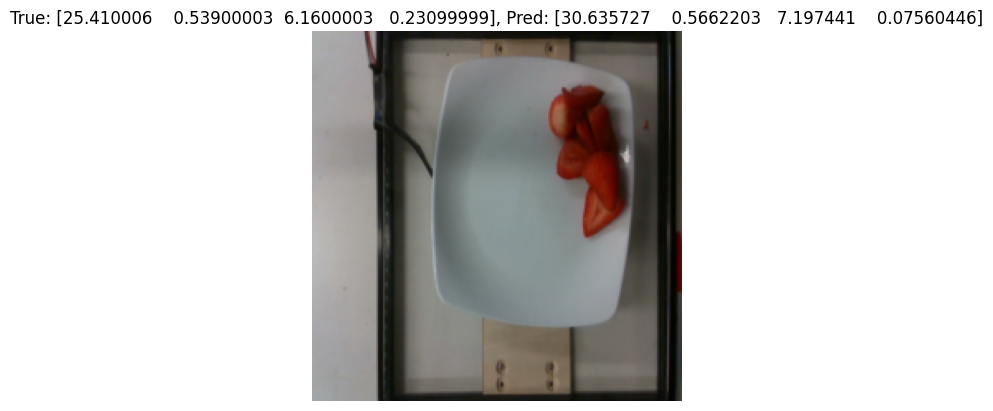

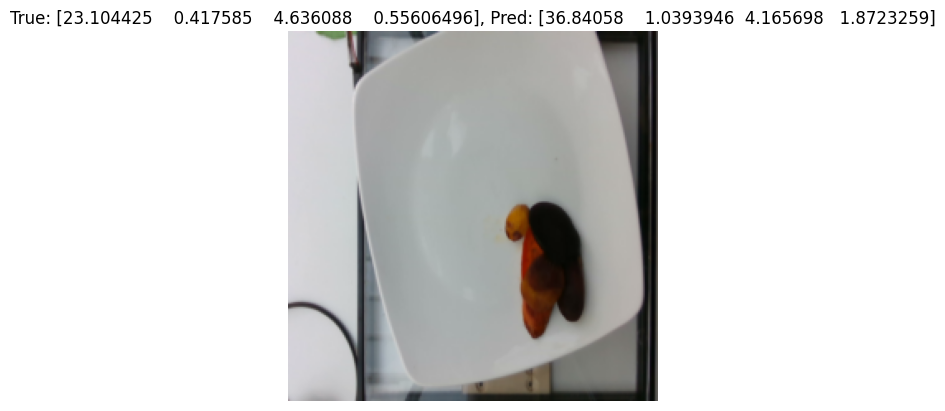

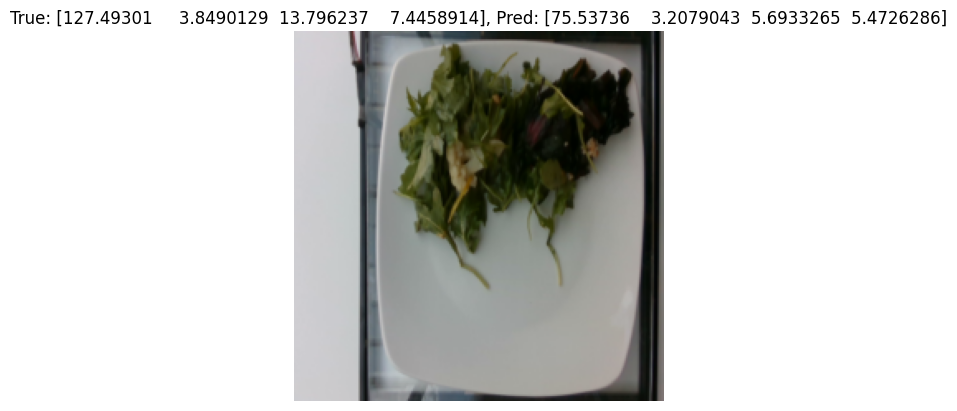

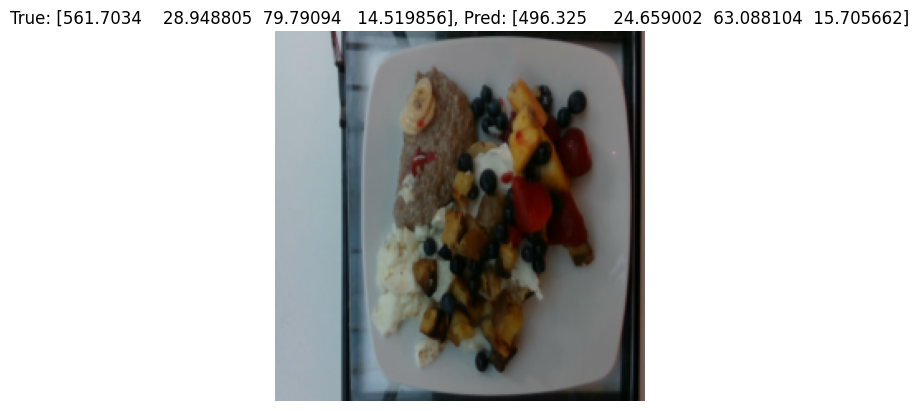

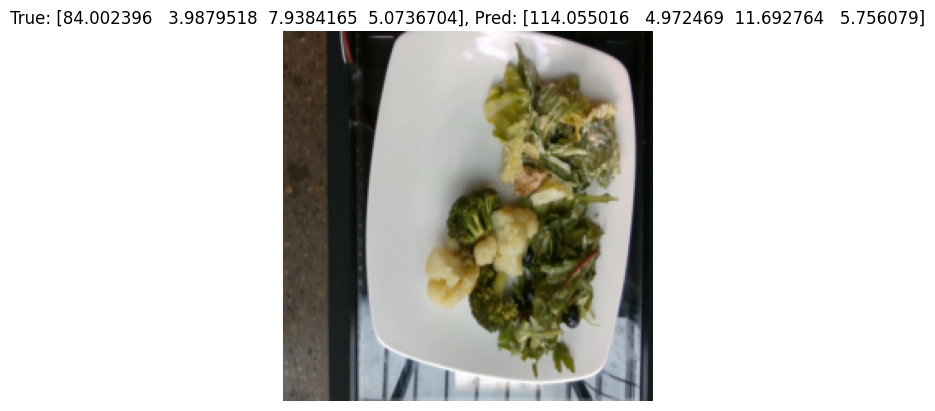

In [44]:
# show some example predictions on the test set with its corresponding images and true values
import matplotlib.pyplot as plt
model.eval()
with torch.no_grad():
    for i in range(5):
        img, label = test_loader.dataset[i]
        img_input = img.unsqueeze(0).to(device)
        output = model(img_input)
        output_real = np.expm1(output.cpu().numpy()[0])

        # denormalize for visualization
        img_vis = denormalize(img.cpu()).clamp(0,1)

        plt.imshow(img_vis.permute(1, 2, 0))
        plt.title(f"True: {np.expm1(label.numpy())}, Pred: {output_real}")
        plt.axis("off")
        plt.show()